<h2 style='color:blue' align='center'>Customer Churn Prediction</h2>


In [1]:
# Install extra dependencies if needed
import sys
!{sys.executable} -m pip install imbalanced-learn xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\tomar\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

%matplotlib inline
print('All libraries loaded.')

All libraries loaded.


## 1. Load & Clean Data

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.sample(5)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5954,7395-XWZOY,Male,0,No,No,20,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),55.00,1165.55,No
323,7102-JJVTX,Female,0,Yes,Yes,9,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Mailed check,48.60,422.3,No
1014,4695-VADHF,Male,0,Yes,Yes,18,Yes,No,DSL,No,...,Yes,No,No,Yes,Month-to-month,No,Electronic check,57.45,990.85,Yes
230,2651-ZCBXV,Male,0,No,No,54,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),108.00,5760.65,No
1453,5899-OUVKV,Male,0,No,No,31,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,2979.2,No


In [4]:
# Drop customerID — no predictive value
df.drop('customerID', axis='columns', inplace=True)

# Remove rows with blank TotalCharges and convert to float
df = df[df.TotalCharges != ' '].copy()
df.TotalCharges = pd.to_numeric(df.TotalCharges)

# Normalise 'No internet service' / 'No phone service' → 'No'
df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)

print('Class distribution:')
print(df['Churn'].value_counts(normalize=True).round(3))

Class distribution:
Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64


## 2. Encode Categorical Features

In [5]:
# Yes/No columns → 1/0
yes_no_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# One-hot encode multi-category columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'])

print('Columns after encoding:', df.shape[1])

Columns after encoding: 27


## 3. Feature Engineering ✨

Adding domain-informed features to help the model distinguish churners better.

In [6]:
# Cost per month of tenure — high value = customer paying a lot relative to how long they've stayed
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Short-tenure customers churn more
df['is_new_customer'] = (df['tenure'] < 6).astype(int)

# Count of add-on services subscribed
service_cols = [
    'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['total_services'] = df[service_cols].sum(axis=1)

# Monthly vs total charges ratio — anomaly signal
df['monthly_to_total'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

print('New features added. Total columns:', df.shape[1])

New features added. Total columns: 31


## 4. Scale & Split

In [7]:
cols_to_scale = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'charges_per_tenure', 'monthly_to_total'
]
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

X = df.drop('Churn', axis='columns')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (5625, 30)  |  Test: (1407, 30)


## 5. Handle Class Imbalance with SMOTE

Only applied to the **training set** — never the test set.

In [8]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE: ', pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {0: 4130, 1: 4130}


## 6. Baseline Model Comparison

In [9]:
baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

results = []
for name, model in baselines.items():
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results.append([
        name,
        round(accuracy_score(y_test, yp), 4),
        round(f1_score(y_test, yp), 4),
        round(roc_auc_score(y_test, prob), 4)
    ])

baseline_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1 (Churn)', 'ROC-AUC'])
baseline_df.sort_values('F1 (Churn)', ascending=False, ignore_index=True)

,Model,Accuracy,F1 (Churn),ROC-AUC
0,Logistic Regression,0.7989,0.5916,0.8412
1,Random Forest,0.7825,0.5460,0.8190
2,Decision Tree,0.7299,0.5141,0.6683


## 7. XGBoost + SMOTE

In [10]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_sm, y_train_sm)

yp_xgb = xgb.predict(X_test)
print('=== XGBoost + SMOTE ===')
print(classification_report(y_test, yp_xgb, target_names=['No Churn', 'Churn']))

=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1033
       Churn       0.54      0.66      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



## 8. Systematic Threshold Tuning

Best threshold: 0.37  →  F1: 0.6102


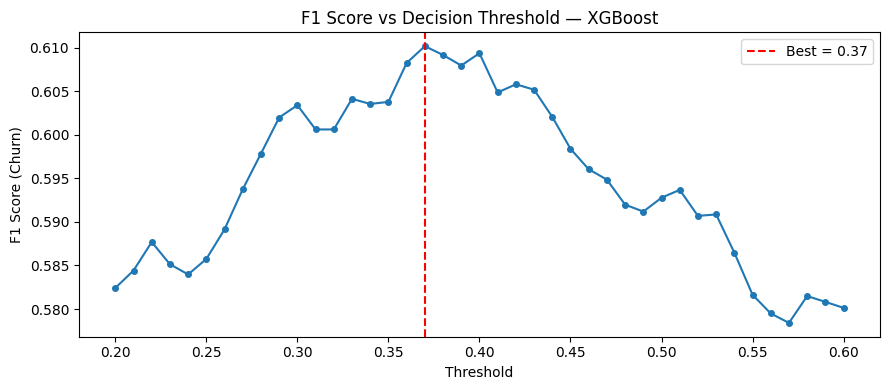

In [11]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
thresholds  = [i / 100 for i in range(20, 61)]
f1_scores   = [f1_score(y_test, (y_prob_xgb > t).astype(int)) for t in thresholds]

best_t = thresholds[f1_scores.index(max(f1_scores))]
print(f'Best threshold: {best_t}  →  F1: {max(f1_scores):.4f}')

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, marker='o', markersize=4)
plt.axvline(best_t, color='red', linestyle='--', label=f'Best = {best_t}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score (Churn)')
plt.title('F1 Score vs Decision Threshold — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

## 9. GridSearchCV — Tune XGBoost for F1

In [12]:
param_grid = {
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'scale_pos_weight': [1, 2],      # directly handles imbalance inside XGBoost
    'n_estimators':     [300, 500],
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    ),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train_sm, y_train_sm)

print('\nBest params:', grid_xgb.best_params_)
print('Best CV F1: ', round(grid_xgb.best_score_, 4))
best_xgb = grid_xgb.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'scale_pos_weight': 2}
Best CV F1:  0.8451


In [13]:
y_prob_tuned  = best_xgb.predict_proba(X_test)[:, 1]
f1s_tuned     = [f1_score(y_test, (y_prob_tuned > t).astype(int)) for t in thresholds]
best_t_tuned  = thresholds[f1s_tuned.index(max(f1s_tuned))]
yp_tuned      = (y_prob_tuned > best_t_tuned).astype(int)

print(f'Tuned XGBoost — threshold: {best_t_tuned}')
print(classification_report(y_test, yp_tuned, target_names=['No Churn', 'Churn']))

Tuned XGBoost — threshold: 0.29
              precision    recall  f1-score   support

    No Churn       0.91      0.67      0.77      1033
       Churn       0.47      0.82      0.60       374

    accuracy                           0.71      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.71      0.72      1407



## 10. Stacking Ensemble (RF + XGBoost → Logistic Regression)

In [14]:
rf_tuned = RandomForestClassifier(
    n_estimators=500, max_depth=12,
    min_samples_leaf=4, class_weight='balanced',
    random_state=42, n_jobs=-1
)


stack = StackingClassifier(
    estimators=[('rf', rf_tuned), ('xgb', best_xgb)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1
)
stack.fit(X_train_sm, y_train_sm)

y_prob_stack = stack.predict_proba(X_test)[:, 1]
f1s_stack    = [f1_score(y_test, (y_prob_stack > t).astype(int)) for t in thresholds]
best_t_stack = thresholds[f1s_stack.index(max(f1s_stack))]
yp_stack     = (y_prob_stack > best_t_stack).astype(int)

print(f'Stacking Ensemble — threshold: {best_t_stack}')
print(classification_report(y_test, yp_stack, target_names=['No Churn', 'Churn']))

Stacking Ensemble — threshold: 0.27
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.72      0.74      1407



## 11. Confusion Matrix — Best Model

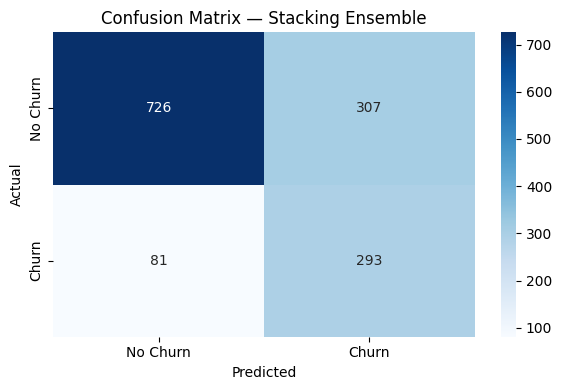

In [15]:
cm = confusion_matrix(y_test, yp_stack)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Stacking Ensemble')
plt.tight_layout()
plt.show()

## 12. Feature Importances

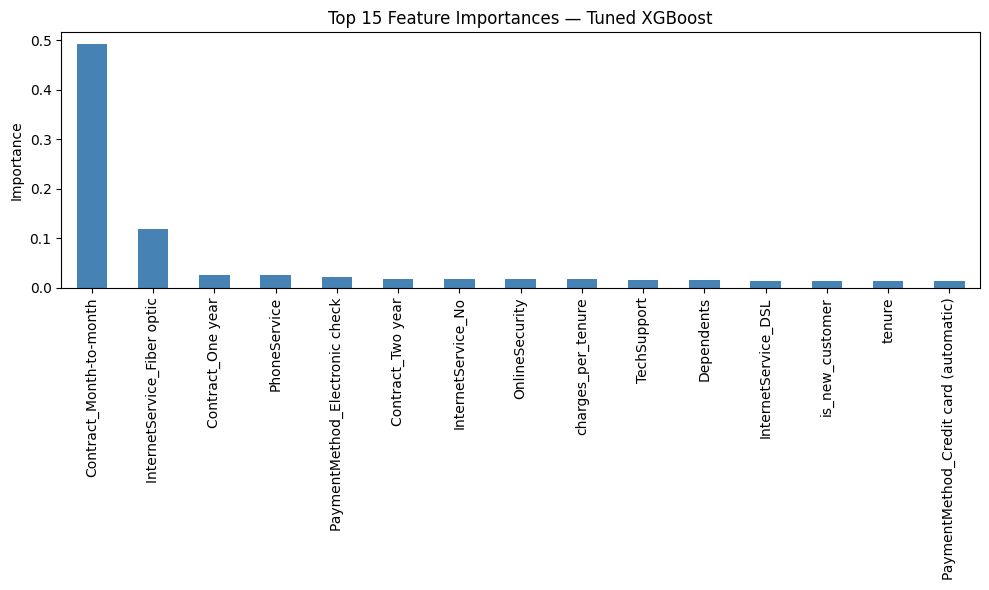

In [16]:
feat_imp = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances — Tuned XGBoost')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 13. Final Summary

In [17]:
summary_data = [
    ['RF (original, no SMOTE)',       f1_score(y_test, baselines['Random Forest'].predict(X_test)),
     accuracy_score(y_test, baselines['Random Forest'].predict(X_test))],
    ['XGBoost + SMOTE',               f1_score(y_test, yp_xgb),
     accuracy_score(y_test, yp_xgb)],
    ['XGBoost tuned + threshold',     f1_score(y_test, yp_tuned),
     accuracy_score(y_test, yp_tuned)],
    ['Stacking + threshold (best)',   f1_score(y_test, yp_stack),
     accuracy_score(y_test, yp_stack)],
]

summary_df = pd.DataFrame(summary_data, columns=['Model', 'F1 (Churn)', 'Accuracy'])
summary_df['F1 (Churn)'] = summary_df['F1 (Churn)'].round(4)
summary_df['Accuracy']   = summary_df['Accuracy'].round(4)
summary_df['F1 Gain vs Original'] = (summary_df['F1 (Churn)'] - summary_df.loc[0, 'F1 (Churn)']).round(4)
summary_df

,Model,F1 (Churn),Accuracy,F1 Gain vs Original
0,"RF (original, no SMOTE)",0.5460,0.7825,0.0000
1,XGBoost + SMOTE,0.5928,0.7598,0.0468
2,XGBoost tuned + threshold,0.5965,0.7058,0.0505
3,Stacking + threshold (best),0.6016,0.7242,0.0556


## 14. Save Model Artifacts for Streamlit App
Run this after training to generate the three files needed by .

In [18]:
## 14. Save Model Artifacts for Streamlit App
import joblib

# Save the stacking model
joblib.dump(stack,  "churn_model.pkl",compress = 9)

# Save the scaler (needed to transform new inputs)
joblib.dump(scaler, "scaler.pkl")

# Save the feature column order (critical for correct predictions)
joblib.dump(list(X.columns), "feature_names.pkl")

print("Saved: churn_model.pkl, scaler.pkl, feature_names.pkl")
print("Run the app with: streamlit run app.py")

Saved: churn_model.pkl, scaler.pkl, feature_names.pkl
Run the app with: streamlit run app.py
